In [1]:
from curl_cffi import requests

url = "https://www.sofascore.com/api/v1/event/14023997/shotmap"

response = requests.get(url)
response.status_code
response.json()

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/116.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'shotmap': [{'player': {'name': 'Bruno Fernandes', 'slug': 'bruno-fernandes', 'shortName': 'B. Fernandes', 'position': 'M', 'jerseyNumber': '8', 'userCount': 252873, 'gender': 'M', 'sofascoreId': 'BrunoFernandes', 'id': 288205, 'fieldTranslations': {'nameTranslation': {'ar': 'برونو فيرنانديز', 'bn': 'ব্রুনো ফার্নান্দেস', 'hi': 'ब्रूनो फर्नांडीस'}, 'shortNameTranslation': {'ar': 'ب. فرنانديز', 'bn': 'বি. ফার্নান্দেস', 'hi': 'बी. फर्नांडीस'}}}, 'isHome': False, 'shotType': 'block', 'situation': 'set-piece', 'playerCoordinates': {'x': 20.1, 'y': 27.8, 'z': 0}, 'bodyPart': 'right-foot', 'goalMouthLocation': 'low-centre', 'goalMouthCoordinates': {'x': 0, 'y': 48.5, 'z': 19}, 'blockCoordinates': {'x': 11.4, 'y': 38.1, 'z': 0}, 'xg': 0.022501960396767, 'xgot': 0, 'goalkeeper': {'name': 'Đorđe Petrović', 'slug': 'dorde-petrovic', 'shortName': 'Đ. Petrović', 'position': 'G', 'jerseyNumber': '1', 'userCount': 8529, 'gender': 'M', 'sofascoreId': 'dj.petrovic12', 'id': 882604, 'fieldTranslati

# I converted it into a DataFrame

In [2]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Bruno Fernandes', 'slug': 'bruno-fer...   False    block   
1  {'name': 'Evanilson', 'slug': 'evanilson', 'sh...    True     miss   
2  {'name': 'David Brooks', 'slug': 'david-brooks...    True    block   
3  {'name': 'Eli Junior Kroupi', 'slug': 'eli-jun...    True     goal   
4  {'name': 'Eli Junior Kroupi', 'slug': 'eli-jun...    True    block   

    situation               playerCoordinates    bodyPart goalMouthLocation  \
0   set-piece  {'x': 20.1, 'y': 27.8, 'z': 0}  right-foot        low-centre   
1    assisted   {'x': 9.9, 'y': 54.4, 'z': 0}        head              high   
2  fast-break    {'x': 19.4, 'y': 36, 'z': 0}   left-foot        low-centre   
3     penalty    {'x': 11.5, 'y': 50, 'z': 0}  right-foot          low-left   
4    assisted  {'x': 24.4, 'y': 30.1, 'z': 0}  right-foot          low-left   

             goalMouthCoordinates                blockCoordinates        xg  \
0    {'

In [3]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s.get("xg", 0) for s in data["shotmap"]],  # Use 0 if xG is missing
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())



              player  team_home shot_type   situation   body_part     x     y  \
0    Bruno Fernandes      False     block   set-piece  right-foot  20.1  27.8   
1          Evanilson       True      miss    assisted        head   9.9  54.4   
2       David Brooks       True     block  fast-break   left-foot  19.4  36.0   
3  Eli Junior Kroupi       True      goal     penalty  right-foot  11.5  50.0   
4  Eli Junior Kroupi       True     block    assisted  right-foot  24.4  30.1   

         xg  minute  
0  0.022502      90  
1  0.046733      90  
2  0.059422      86  
3  0.788400      81  
4  0.016906      78  


In [4]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Bruno Fernandes,False,block,set-piece,right-foot,20.1,27.8,0.022502,90
1,Evanilson,True,miss,assisted,head,9.9,54.4,0.046733,90
2,David Brooks,True,block,fast-break,left-foot,19.4,36.0,0.059422,86
3,Eli Junior Kroupi,True,goal,penalty,right-foot,11.5,50.0,0.788400,81
4,Eli Junior Kroupi,True,block,assisted,right-foot,24.4,30.1,0.016906,78


In [35]:
shots_df.to_csv("shots.csv", index=False)
from google.colab import files
files.download("shots.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Separate the teams

In [5]:
Bournemouth = shots_df[shots_df["team_home"] == True]
Manchester_United = shots_df[shots_df["team_home"] == False]

# number of shots per team

In [6]:
shots_df.groupby("team_home")["shot_type"].count()

,shot_type
team_home,
False,15
True,16


# Total shots per player

In [7]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

               player  Total_Shots
0     Adrien Truffert            1
1          Alex Scott            2
2         Amad Diallo            2
3     Bruno Fernandes            6
4        Bryan Mbeumo            1
5        David Brooks            1
6         Diogo Dalot            1
7   Eli Junior Kroupi            2
8           Evanilson            1
9       Harry Maguire            1
10         James Hill            1
11          Leny Yoro            1
12      Marcos Senesi            1
13   Marcus Tavernier            2
14      Matheus Cunha            2
15              Rayan            3
16      Ryan Christie            2
17       Álex Jiménez            1


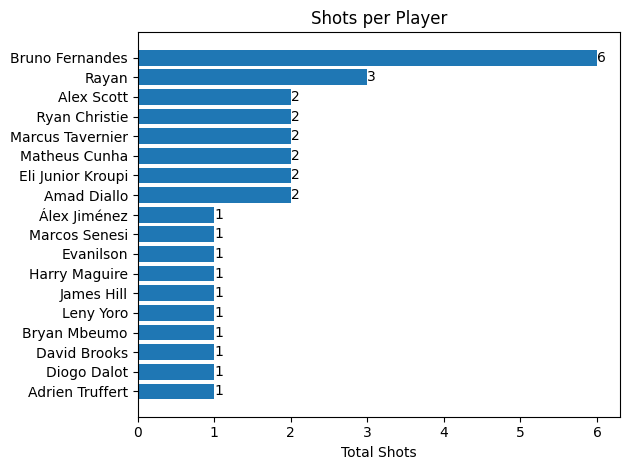

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = {
    "player": [
        "Adrien Truffert","Alex Scott","Amad Diallo","Bruno Fernandes",
        "Bryan Mbeumo","David Brooks","Diogo Dalot","Eli Junior Kroupi",
        "Evanilson","Harry Maguire","James Hill","Leny Yoro","Marcos Senesi",
        "Marcus Tavernier","Matheus Cunha","Rayan"," Ryan Christie","Álex Jiménez"
    ],
    "shots": [1,2,2,6,1,1,1,2,1,1,1,1,1,2,2,3,2,1]
}

df = pd.DataFrame(data)

# Sort values
df = df.sort_values(by="shots", ascending=True)

# Plot
plt.figure()
bars = plt.barh(df["player"], df["shots"])

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f"{int(width)}", va='center')

plt.xlabel("Total Shots")
plt.title("Shots per Player")
plt.tight_layout()
plt.show()

# Dangerous Shooters

In [9]:
shots_df.groupby("player")["xg"].sum().sort_values(ascending=False)

,xg
player,
Bruno Fernandes,1.136337
Eli Junior Kroupi,0.805306
Rayan,0.405037
Marcus Tavernier,0.255117
Amad Diallo,0.217862
Leny Yoro,0.158945
Ryan Christie,0.101168
Harry Maguire,0.066080
David Brooks,0.059422


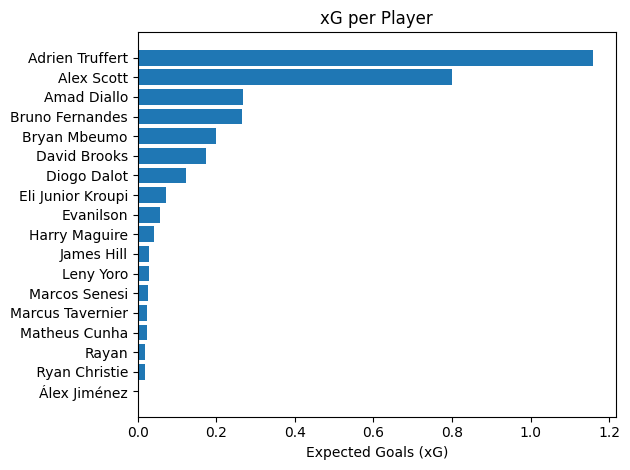

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = {
    "player": [
       "Adrien Truffert","Alex Scott","Amad Diallo","Bruno Fernandes",
        "Bryan Mbeumo","David Brooks","Diogo Dalot","Eli Junior Kroupi",
        "Evanilson","Harry Maguire","James Hill","Leny Yoro","Marcos Senesi",
        "Marcus Tavernier","Matheus Cunha","Rayan"," Ryan Christie","Álex Jiménez"
    ],
    "xg": [
        1.159229,0.800080,0.267399,0.266609,0.198796,0.174385,0.122538,0.072889,
        0.055918,0.041321,0.029279,0.027992,0.026909,0.024709,0.024607,0.018147,
        0.017812,0.000000
    ]
}

df = pd.DataFrame(data)

# Sort values (important!)
df = df.sort_values(by="xg", ascending=True)


# Plot
plt.figure()
plt.barh(df["player"], df["xg"])
plt.xlabel("Expected Goals (xG)")
plt.title("xG per Player")
plt.tight_layout()
plt.show()

# Team total Expected goals (xG)

In [11]:
shots_df.groupby("team_home")["xg"].sum()

,xg
team_home,
False,1.678503
True,1.804320


# Comparing shot and Expected goal

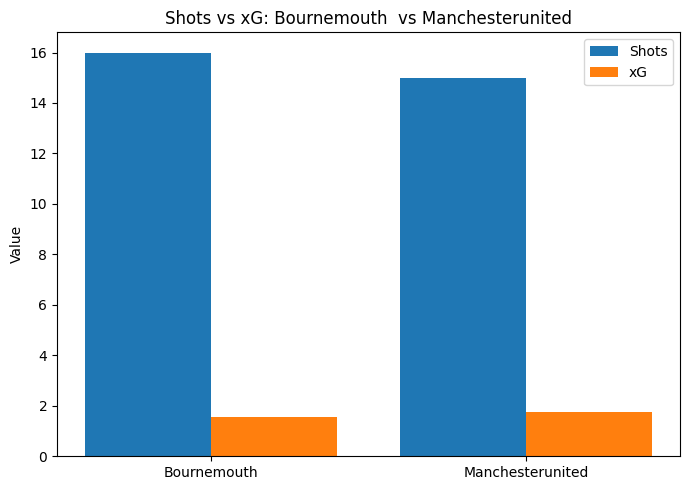

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Team": ["Bournemouth", "Manchesterunited"],
    "Shots": [16, 15],
    "xG": [1.56, 1.77]
}

df = pd.DataFrame(data)

x = range(len(df))

plt.figure(figsize=(7,5))

plt.bar(x, df["Shots"], width=0.4, label="Shots")
plt.bar([i + 0.4 for i in x], df["xG"], width=0.4, label="xG")

plt.xticks([i + 0.2 for i in x], df["Team"])
plt.ylabel("Value")
plt.title("Shots vs xG: Bournemouth  vs Manchesterunited")
plt.legend()

plt.tight_layout()
plt.show()

# number of situation per team

In [13]:
# Count shots per situation for each team
situation_counts = shots_df.groupby("team_home")["situation"].value_counts()
print(situation_counts)

team_home  situation         
False      assisted              7
           corner                5
           fast-break            1
           penalty               1
           set-piece             1
True       assisted              7
           fast-break            3
           regular               2
           corner                1
           free-kick             1
           penalty               1
           throw-in-set-piece    1
Name: count, dtype: int64


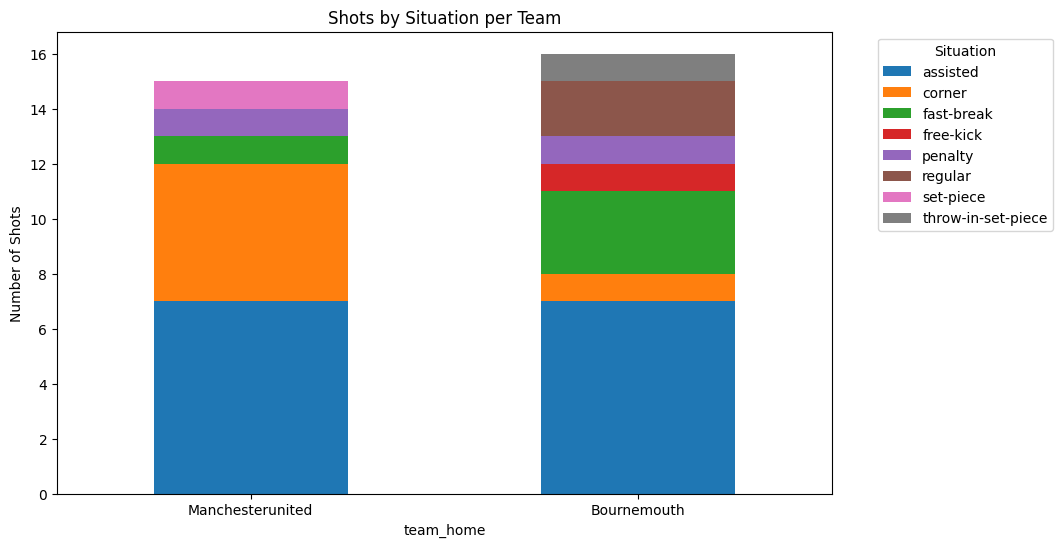

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample data
data = {
    ('False','assisted'):7,
    ('False','corner'):5,
    ('False','fast-break'):1,
    ('False','penalty'):1,
    ('False','set-piece'):1,
    ('True','assisted'):7,
    ('True','fast-break'):3,
    ('True','regular'):2,
    ('True','corner'):1,
    ('True','free-kick'):1,
    ('True','penalty'):1,
    ('True','throw-in-set-piece'):1
}

# Convert to DataFrame
df = pd.DataFrame(list(data.items()), columns=['team_situation', 'count'])
df[['team_home','situation']] = pd.DataFrame(df['team_situation'].tolist(), index=df.index)
df.drop('team_situation', axis=1, inplace=True)

# Pivot for stacked bar chart
pivot_df = df.pivot(index='team_home', columns='situation', values='count').fillna(0)

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel("Number of Shots")
plt.title("Shots by Situation per Team")
plt.xticks(ticks=[0,1], labels=['Manchesterunited','Bournemouth'], rotation=0)
plt.legend(title='Situation', bbox_to_anchor=(1.05, 1))
plt.show()

#number of situation per team and player

In [15]:
# Count number of shots per player per situation, keeping team info
situation_counts = shots_df.groupby(["team_home", "player"])["situation"].value_counts().reset_index(name="shots")
print(situation_counts)

    team_home             player           situation  shots
0       False        Amad Diallo            assisted      2
1       False    Bruno Fernandes            assisted      3
2       False    Bruno Fernandes          fast-break      1
3       False    Bruno Fernandes             penalty      1
4       False    Bruno Fernandes           set-piece      1
5       False       Bryan Mbeumo              corner      1
6       False        Diogo Dalot            assisted      1
7       False      Harry Maguire              corner      1
8       False         James Hill              corner      1
9       False          Leny Yoro              corner      1
10      False      Matheus Cunha            assisted      1
11      False      Matheus Cunha              corner      1
12       True    Adrien Truffert              corner      1
13       True         Alex Scott            assisted      1
14       True         Alex Scott  throw-in-set-piece      1
15       True       David Brooks        

# shot type per team

In [16]:
shot_type_counts = shots_df.groupby("team_home")["shot_type"].value_counts()
print(shot_type_counts)

team_home  shot_type
False      block        7
           save         4
           goal         2
           miss         2
True       miss         6
           block        4
           save         3
           goal         2
           post         1
Name: count, dtype: int64


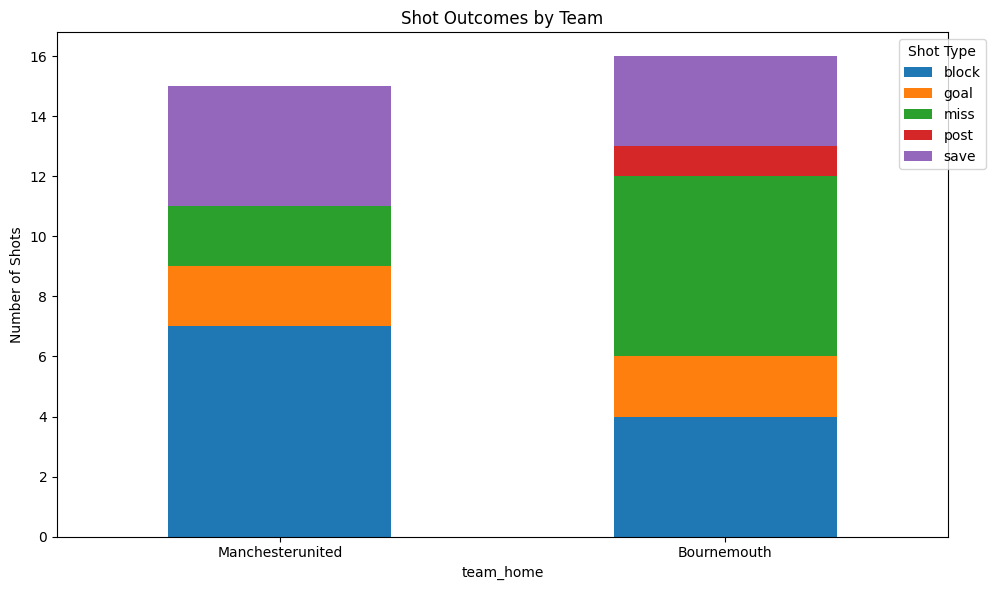

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
data = {
    ('False','block'):7,
    ('False','save'):4,
    ('False','goal'):2,
    ('False','miss'):2,
    ('True','miss'):6,
    ('True','block'):4,
    ('True','save'):3,
    ('True','goal'):2,
    ('True','post'):1
}

df = pd.DataFrame(list(data.items()), columns=['team_shot','count'])
df[['team_home','shot_type']] = pd.DataFrame(df['team_shot'].tolist(), index=df.index)
df.drop('team_shot', axis=1, inplace=True)

# Pivot
pivot_df = df.pivot(index='team_home', columns='shot_type', values='count').fillna(0)

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xticks(ticks=[0,1], labels=['Manchesterunited','Bournemouth'], rotation=0)
plt.ylabel("Number of Shots")
plt.title("Shot Outcomes by Team")
plt.legend(title="Shot Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# Shot outcome per team and player

In [18]:
# Count number of shots per player per situation, keeping team info
shot_type_counts = shots_df.groupby(["team_home", "player"])["shot_type"].value_counts().reset_index(name="shots")
print(shot_type_counts)

    team_home             player shot_type  shots
0       False        Amad Diallo     block      1
1       False        Amad Diallo      save      1
2       False    Bruno Fernandes     block      3
3       False    Bruno Fernandes      save      2
4       False    Bruno Fernandes      goal      1
5       False       Bryan Mbeumo     block      1
6       False        Diogo Dalot      miss      1
7       False      Harry Maguire     block      1
8       False         James Hill      goal      1
9       False          Leny Yoro      miss      1
10      False      Matheus Cunha     block      1
11      False      Matheus Cunha      save      1
12       True    Adrien Truffert      save      1
13       True         Alex Scott     block      1
14       True         Alex Scott      post      1
15       True       David Brooks     block      1
16       True  Eli Junior Kroupi     block      1
17       True  Eli Junior Kroupi      goal      1
18       True          Evanilson      miss      1


In [34]:
# Count number of shots per player per situation, keeping team info
shot_type_counts = shots_df.groupby(["team_home", "player","situation"])["shot_type"].value_counts().reset_index(name="shots")
print(shot_type_counts)

    team_home             player           situation shot_type  shots
0       False        Amad Diallo            assisted     block      1
1       False        Amad Diallo            assisted      save      1
2       False    Bruno Fernandes            assisted      save      2
3       False    Bruno Fernandes            assisted     block      1
4       False    Bruno Fernandes          fast-break     block      1
5       False    Bruno Fernandes             penalty      goal      1
6       False    Bruno Fernandes           set-piece     block      1
7       False       Bryan Mbeumo              corner     block      1
8       False        Diogo Dalot            assisted      miss      1
9       False      Harry Maguire              corner     block      1
10      False         James Hill              corner      goal      1
11      False          Leny Yoro              corner      miss      1
12      False      Matheus Cunha            assisted      save      1
13      False      M

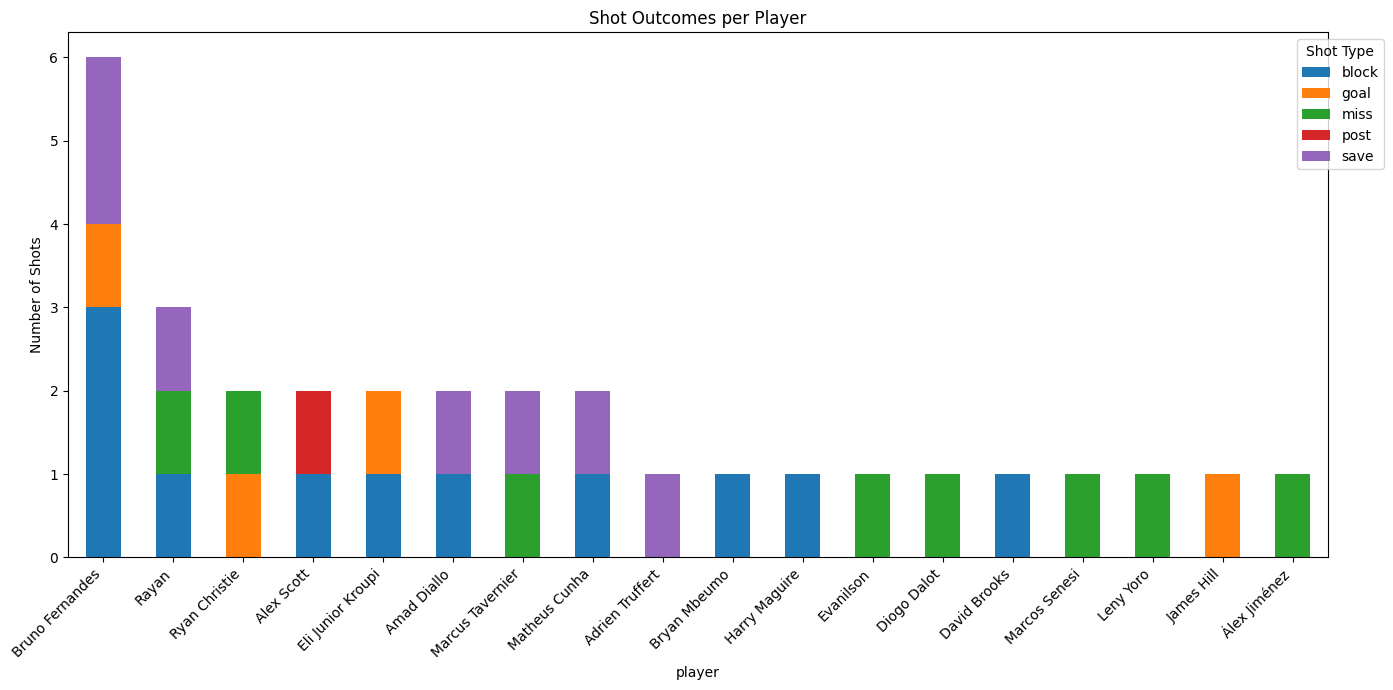

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df
pivot_df = shots_df.pivot_table(
    index='player',
    columns='shot_type',
    aggfunc='size',
    fill_value=0
)

# Sort by total involvement
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='total', ascending=False)
pivot_df.drop('total', axis=1, inplace=True)

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(14,7))
plt.ylabel("Number of Shots")
plt.title("Shot Outcomes per Player")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Shot Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# Shots by body part

In [20]:
shots_df["body_part"].value_counts()

,count
body_part,
right-foot,19
left-foot,9
head,3


# shot by body part per player

In [21]:
# Count number of shots per player per situation, keeping team info
body_part_counts = shots_df.groupby(["team_home", "player"])["body_part"].value_counts().reset_index(name="shots")
print(body_part_counts)

    team_home             player   body_part  shots
0       False        Amad Diallo  right-foot      2
1       False    Bruno Fernandes  right-foot      6
2       False       Bryan Mbeumo  right-foot      1
3       False        Diogo Dalot  right-foot      1
4       False      Harry Maguire  right-foot      1
5       False         James Hill        head      1
6       False          Leny Yoro        head      1
7       False      Matheus Cunha   left-foot      1
8       False      Matheus Cunha  right-foot      1
9        True    Adrien Truffert   left-foot      1
10       True         Alex Scott  right-foot      2
11       True       David Brooks   left-foot      1
12       True  Eli Junior Kroupi  right-foot      2
13       True          Evanilson        head      1
14       True      Marcos Senesi   left-foot      1
15       True   Marcus Tavernier   left-foot      2
16       True              Rayan   left-foot      2
17       True              Rayan  right-foot      1
18       Tru

In [22]:
# Aggregate shots by player & body part
bodypart_player = shots_df.groupby(['player', 'body_part']).agg(
    shots=('body_part', 'count'),
    xg=('xg', 'sum')
).reset_index()

print(bodypart_player)

               player   body_part  shots        xg
0     Adrien Truffert   left-foot      1  0.041367
1          Alex Scott  right-foot      2  0.048417
2         Amad Diallo  right-foot      2  0.217862
3     Bruno Fernandes  right-foot      6  1.136337
4        Bryan Mbeumo  right-foot      1  0.024476
5        David Brooks   left-foot      1  0.059422
6         Diogo Dalot  right-foot      1  0.020530
7   Eli Junior Kroupi  right-foot      2  0.805306
8           Evanilson        head      1  0.046733
9       Harry Maguire  right-foot      1  0.066080
10         James Hill        head      1  0.000000
11          Leny Yoro        head      1  0.158945
12      Marcos Senesi   left-foot      1  0.015256
13   Marcus Tavernier   left-foot      2  0.255117
14      Matheus Cunha   left-foot      1  0.036882
15      Matheus Cunha  right-foot      1  0.017391
16              Rayan   left-foot      2  0.038635
17              Rayan  right-foot      1  0.366402
18      Ryan Christie   left-fo

# Which body part produced the highest quality chances?

In [23]:
bodypart_xg = shots_df.groupby('body_part')['xg'].sum().reset_index()

# Sort for better visualization
bodypart_xg = bodypart_xg.sort_values(by='xg', ascending=False)

print(bodypart_xg)

    body_part        xg
2  right-foot  2.793518
1   left-foot  0.483626
0        head  0.205678


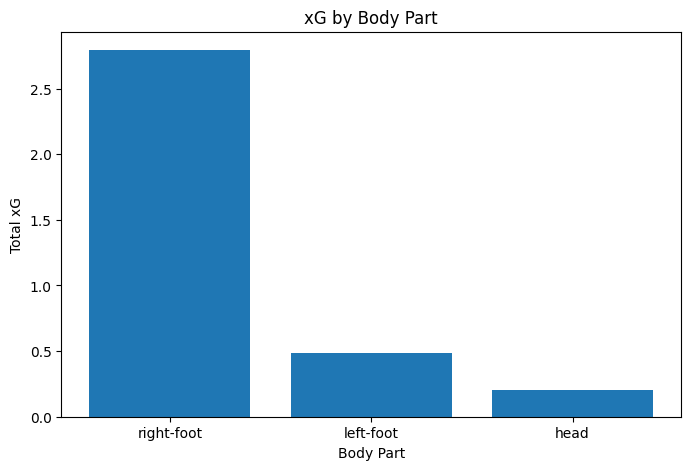

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(bodypart_xg['body_part'], bodypart_xg['xg'])
plt.ylabel("Total xG")
plt.xlabel("Body Part")
plt.title("xG by Body Part")
plt.xticks(rotation=0)
plt.show()

# Plot shot map

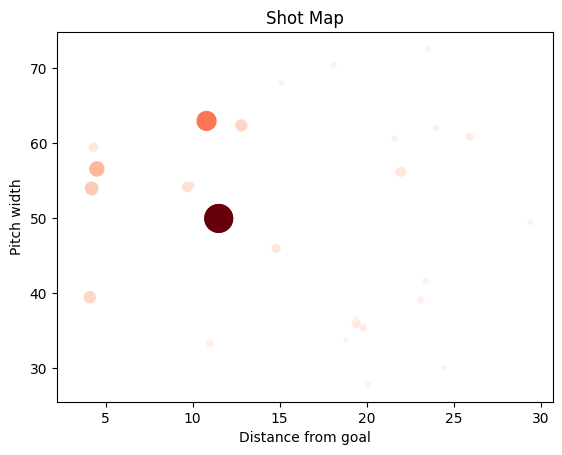

In [25]:
plt.scatter(shots_df["x"], shots_df["y"], c=shots_df["xg"], s=shots_df["xg"]*500, cmap="Reds")
plt.xlabel("Distance from goal")
plt.ylabel("Pitch width")
plt.title("Shot Map")
plt.show()

In [26]:
Bournemouth = shots_df[shots_df["team_home"] == True]
Manchester_united = shots_df[shots_df["team_home"] == False]

# Plot the home team shots

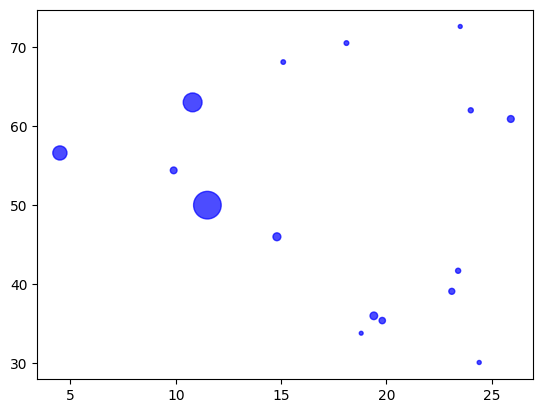

In [27]:
plt.scatter(
    Bournemouth["x"],
    Bournemouth["y"],
    s=Bournemouth["xg"]*500,
    c="blue",
    edgecolor="blue",
    alpha=0.7,
    label="Bournemouth"
)

# Plot the away team shots

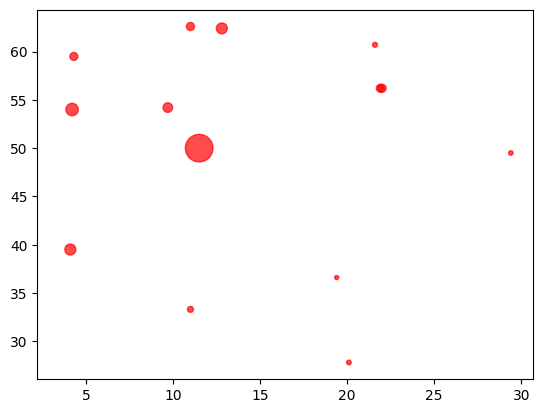

In [28]:
plt.scatter(
    Manchester_united["x"],
    Manchester_united["y"],
    s=Manchester_united["xg"]*500,
    c="red",
    edgecolor="red",
    alpha=0.7,
    label="Manchester_united"
)

In [29]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.7 MB/s eta 0:00:00


# Both teams shots map

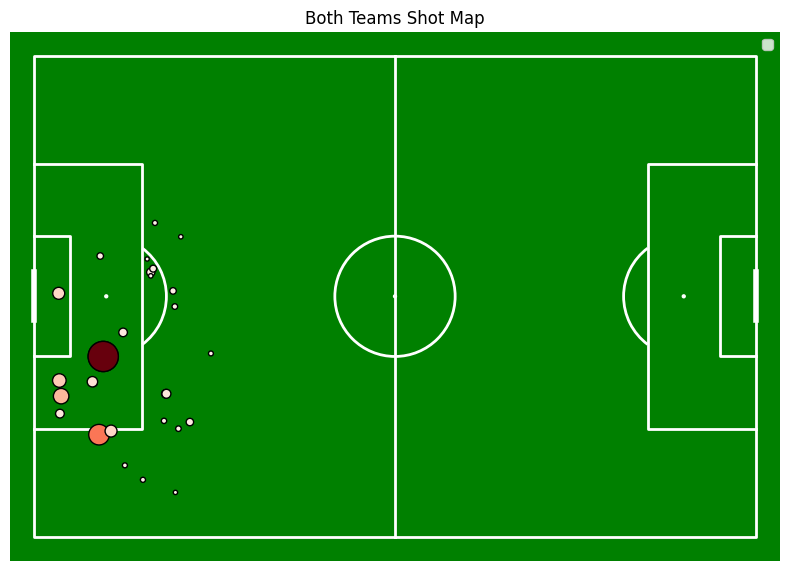

In [30]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    shots_df["x"],
    shots_df["y"],
    s=shots_df["xg"]*600,
    c=shots_df["xg"],
    cmap="Reds",
    edgecolors="black",
    ax=ax
)

plt.title("Both Teams Shot Map")
plt.legend()
plt.show()

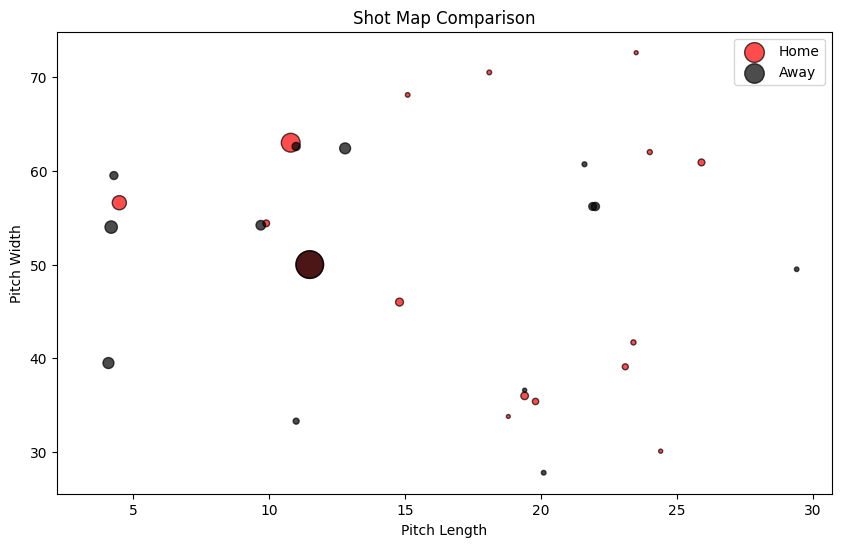

In [31]:
plt.figure(figsize=(10,6))

home = shots_df[shots_df["team_home"] == True]
away = shots_df[shots_df["team_home"] == False]

plt.scatter(home["x"], home["y"], s=home["xg"]*500,
            c="red", edgecolor="black", alpha=0.7, label="Home")

plt.scatter(away["x"], away["y"], s=away["xg"]*500,
            c="black", edgecolor="black", alpha=0.7, label="Away")

plt.title("Shot Map Comparison")
plt.xlabel("Pitch Length")
plt.ylabel("Pitch Width")
plt.legend()

plt.show()

# Home Team shots map

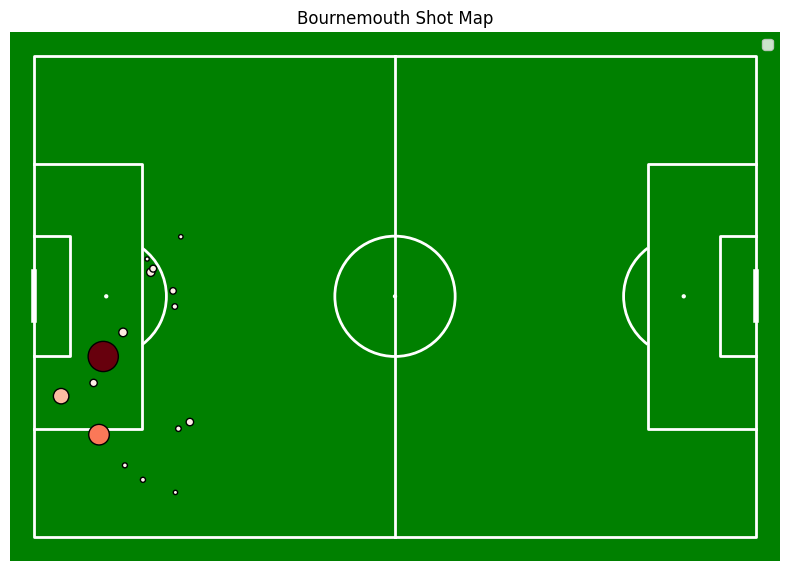

In [32]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    Bournemouth["x"],
    Bournemouth["y"],
    s=Bournemouth["xg"]*600,
    c=Bournemouth["xg"],
    cmap="Reds",
    edgecolors="black",
    ax=ax
)

plt.title("Bournemouth Shot Map")
plt.legend()
plt.show()

# Insight
Bournemouth’s attacking play was concentrated inside the penalty area, with a clear focus on high-probability shooting zones. While they generated one high-quality chance, most attempts were of low-to-moderate xG, suggesting limited creation of clear-cut opportunities.”

# Away Team shots map

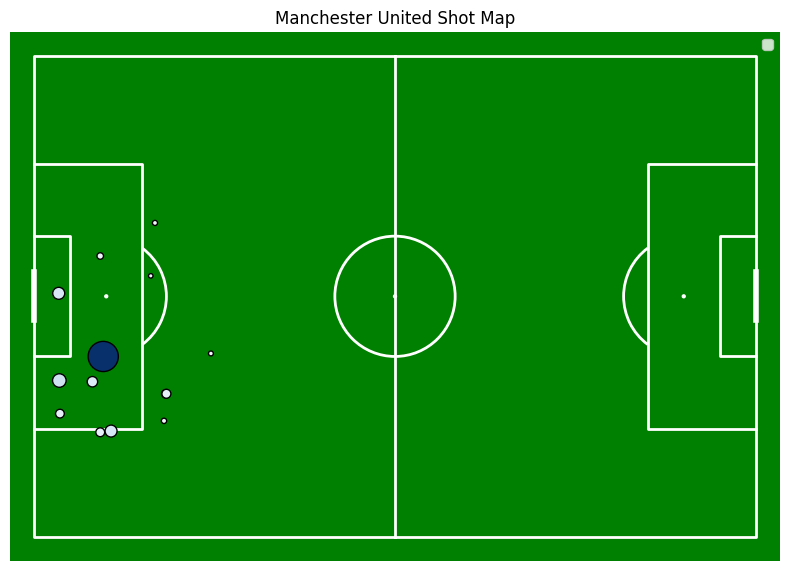

In [33]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    Manchester_united["x"],
    Manchester_united["y"],
    s=Manchester_united["xg"]*600,
    c=Manchester_united["xg"],
    cmap="Blues",
    edgecolors="black",
    ax=ax
)

plt.title("Manchester United Shot Map")
plt.legend()
plt.show()

# Insight
Manchester **united** attacking play was concentrated inside the penalty area, with a clear focus on high-probability shooting zones. While they generated one high-quality chance, most attempts were of low-to-moderate xG, suggesting limited creation of clear-cut opportunities.”